# Task 1: Data Preparation

In [1]:
# Required Imports
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import torch
from transformers import AutoModel, AutoTokenizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK resources (run once)


In [2]:
print("Downloading NLTK resources...")
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    nltk.download('punkt_tab')
    print("NLTK resources downloaded successfully.")
except Exception as e:
    print(f"Error downloading NLTK resources: {e}")
    print("Please ensure you have an internet connection or try running nltk.download() manually.")


NLTK resources downloaded successfully.


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mujtaba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# Define the data
texts = [
    "This movie is fantastic and I love it.",
    "The acting was great but the plot was weak.",
    "A terrible film, completely boring.",
    "I hated every minute of this production.",
    "Wonderful cinematography and compelling story.",
    "Bad script and poor direction.",
    "An absolute masterpiece, highly recommend.",
    "Utterly disappointing experience.",
    "Enjoyed it thoroughly, a real gem.",
    "Skip this one, it's a waste of time.",
    "The food was delicious and the service was excellent.",
    "Didn't like the atmosphere, too noisy.",
    "A truly unique and enjoyable experience.",
    "The product broke after only a week.",
    "Highly satisfied with my purchase.",
    "The customer support was unhelpful.",
    "What a fantastic performance!",
    "Quite boring, nothing special.",
    "Loved the vibrant colors and design.",
    "The instructions were unclear and confusing.",
    "Would definitely visit again.",
    "Overpriced for what you get.",
    "A pleasant surprise, much better than expected.",
    "Poor quality materials used.",
    "Seamless transaction and fast delivery.",
    "The ending was very predictable.",
    "Outstanding craftsmanship.",
    "Left feeling disappointed.",
    "So happy with the results!",
    "Could have been much better."
]

In [4]:
# Simple sentiment labels (1: positive, 0: negative/neutral)
labels = [
    1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]


In [5]:
# Create a DataFrame
df = pd.DataFrame({'text': texts, 'label': labels})
print("Original Data:")
print(df)
print(f"\nTotal number of examples: {len(df)}")


Original Data:
                                                 text  label
0              This movie is fantastic and I love it.      1
1         The acting was great but the plot was weak.      0
2                 A terrible film, completely boring.      0
3            I hated every minute of this production.      0
4      Wonderful cinematography and compelling story.      1
5                      Bad script and poor direction.      0
6          An absolute masterpiece, highly recommend.      1
7                   Utterly disappointing experience.      0
8                  Enjoyed it thoroughly, a real gem.      1
9                Skip this one, it's a waste of time.      0
10  The food was delicious and the service was exc...      1
11             Didn't like the atmosphere, too noisy.      0
12           A truly unique and enjoyable experience.      1
13               The product broke after only a week.      0
14                 Highly satisfied with my purchase.      1
15       

In [6]:
# Preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic characters
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

In [7]:
df['processed_text'] = df['text'].apply(preprocess_text)
print("\nProcessed Data (first 5 rows):")
print(df.head())


Processed Data (first 5 rows):
                                             text  label  \
0          This movie is fantastic and I love it.      1   
1     The acting was great but the plot was weak.      0   
2             A terrible film, completely boring.      0   
3        I hated every minute of this production.      0   
4  Wonderful cinematography and compelling story.      1   

                              processed_text  
0                       movie fantastic love  
1                     acting great plot weak  
2            terrible film completely boring  
3              hated every minute production  
4  wonderful cinematography compelling story  


In [8]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['processed_text'], df['label'], test_size=0.3, random_state=42, stratify=df['label'])


In [9]:
print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Train set label distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set label distribution:\n{y_test.value_counts(normalize=True)}")


Train set size: 21
Test set size: 9
Train set label distribution:
label
0    0.52381
1    0.47619
Name: proportion, dtype: float64
Test set label distribution:
label
0    0.555556
1    0.444444
Name: proportion, dtype: float64


# 2. Implementing Sparse Representations

In [10]:
# Bag-of-Words (BoW)
vectorizer_bow = CountVectorizer()
X_train_bow = vectorizer_bow.fit_transform(X_train)
X_test_bow = vectorizer_bow.transform(X_test)
print("\n--- Bag-of-Words ---")
print("Vocabulary size:", len(vectorizer_bow.vocabulary_))
print("Train BoW matrix shape:", X_train_bow.shape)
print("Test BoW matrix shape:", X_test_bow.shape)


--- Bag-of-Words ---
Vocabulary size: 66
Train BoW matrix shape: (21, 66)
Test BoW matrix shape: (9, 66)


In [11]:
# TF-IDF
vectorizer_tfidf = TfidfVectorizer()
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)
print("\n--- TF-IDF ---")
print("Vocabulary size:", len(vectorizer_tfidf.vocabulary_))
print("Train TF-IDF matrix shape:", X_train_tfidf.shape)
print("Test TF-IDF matrix shape:", X_test_tfidf.shape)


--- TF-IDF ---
Vocabulary size: 66
Train TF-IDF matrix shape: (21, 66)
Test TF-IDF matrix shape: (9, 66)


# 3. Exploring Dense Representations

In [12]:
# Using Pre-trained Embeddings (Sentence Transformers via Hugging Face)
# Load model and tokenizer
model_name = 'sentence-transformers/all-MiniLM-L6-v2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [14]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] # First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [15]:
# Function to get embeddings
def get_embeddings(texts):
    encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    with torch.no_grad():
        model_output = model(**encoded_input)
    # Mean pooling to get a single vector representation for each sentence
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    return sentence_embeddings.numpy()

In [16]:
X_train_dense = get_embeddings(X_train.tolist())
X_test_dense = get_embeddings(X_test.tolist())
print("\n--- Dense Embeddings ---")
print("Train Dense matrix shape:", X_train_dense.shape)
print("Test Dense matrix shape:", X_test_dense.shape)


--- Dense Embeddings ---
Train Dense matrix shape: (21, 384)
Test Dense matrix shape: (9, 384)


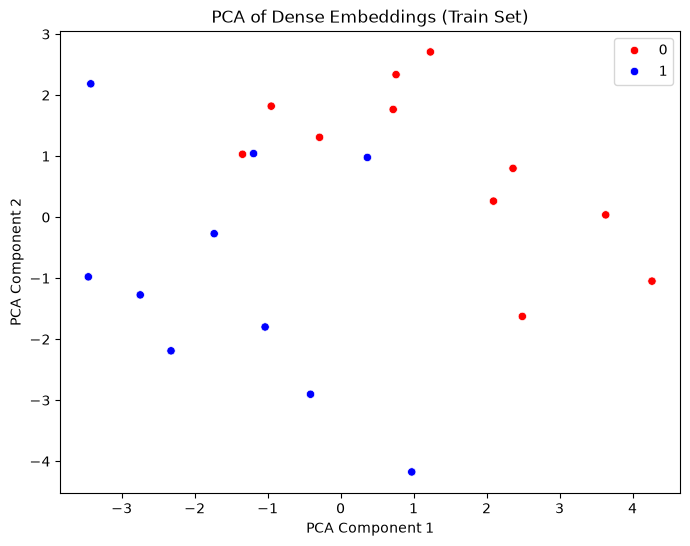

In [17]:
# Visualize Dense Representations (using PCA)
# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_dense)
plt.figure(figsize=(8, 6))

# Use the original index from the split to map labels correctly
train_indices = X_train.index
colors = ['red' if label == 0 else 'blue' for label in y_train]
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train.tolist(), palette=['red', 'blue'], legend='full')
plt.title('PCA of Dense Embeddings (Train Set)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


# 4. Comparing Representations in a Classification Task

In [19]:
# We will train a simple Logistic Regression model on each representation.
# Classifier Training and Evaluation
def train_and_evaluate(X_train, X_test, y_train, y_test, representation_name):
    print(f"\n--- Evaluating with {representation_name} ---")
    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


In [20]:
# Evaluate BoW
train_and_evaluate(X_train_bow, X_test_bow, y_train, y_test, "Bag-of-Words")


--- Evaluating with Bag-of-Words ---
Accuracy: 0.6667
Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       1.00      0.25      0.40         4

    accuracy                           0.67         9
   macro avg       0.81      0.62      0.58         9
weighted avg       0.79      0.67      0.61         9



In [21]:
# Evaluate TF-IDF
train_and_evaluate(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF")


--- Evaluating with TF-IDF ---
Accuracy: 0.6667
Classification Report:
              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       1.00      0.25      0.40         4

    accuracy                           0.67         9
   macro avg       0.81      0.62      0.58         9
weighted avg       0.79      0.67      0.61         9



In [22]:
# Evaluate Dense Embeddings
train_and_evaluate(X_train_dense, X_test_dense, y_train, y_test, "Dense Embeddings")


--- Evaluating with Dense Embeddings ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



In [23]:
# Evaluate Dense Embeddings
train_and_evaluate(X_train_dense, X_test_dense, y_train, y_test, "Dense Embeddings")


--- Evaluating with Dense Embeddings ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9

